In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import gzip
import matplotlib.pyplot as plt

from pems_utils import y_weighted_fill_or_smooth, find_congestion_blocks_merged, filter_congestion_blocks, plot_matrix, process_pems

plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.titlesize": 13,
    "figure.facecolor": "white",
})

data_dir = Path("../data/d12_feb_data")

cols = [
    "timestamp",
    "station_id",
    "district",
    "freeway",
    "direction_of_travel",
    "lane_type",
    "station_length",
    "samples",
    "percent_observed",
    "total_flow",
    "avg_occupancy",
    "avg_speed",
    "lane_1_samples",
    "lane_1_flow",
    "lane_1_avg_occupancy",
    "lane_1_avg_speed",
    "lane_1_observed",
    "lane_2_samples",
    "lane_2_flow",
    "lane_2_avg_occupancy",
    "lane_2_avg_speed",
    "lane_2_observed",    
    "lane_3_samples",
    "lane_3_flow",
    "lane_3_avg_occupancy",
    "lane_3_avg_speed",
    "lane_3_observed",
    "lane_4_samples",
    "lane_4_flow",
    "lane_4_avg_occupancy",
    "lane_4_avg_speed",
    "lane_4_observed",   
    "lane_5_samples",
    "lane_5_flow",
    "lane_5_avg_occupancy",
    "lane_5_avg_speed",
    "lane_5_observed",
    "lane_6_samples",
    "lane_6_flow",
    "lane_6_avg_occupancy",
    "lane_6_avg_speed",
    "lane_6_observed",
    "lane_7_samples",
    "lane_7_flow",
    "lane_7_avg_occupancy",
    "lane_7_avg_speed",
    "lane_7_observed",
    "lane_8_samples",
    "lane_8_flow",
    "lane_8_avg_occupancy",
    "lane_8_avg_speed",
    "lane_8_observed"
]

daily_dfs = {}

for p in sorted(data_dir.glob("*.txt.gz")):
    # detect delimiter from first line
    with gzip.open(p, "rt") as f:
        first = f.readline()
    sep = "\t" if first.count("\t") > first.count(",") else ","

    df = pd.read_csv(
        p,
        compression="gzip",
        sep=sep,
        header=None,      # key: file has no usable header row
        names=cols,       # force column names in this exact order
        low_memory=False,
    )

    daily_dfs[p.stem.replace(".txt", "")] = df

In [2]:
# 1) combine all dfs from the dictionary
master_df = pd.concat(daily_dfs.values(), ignore_index=True)

# 2) filter: freeway == 5 and direction_of_travel == "S"
# (cast freeway to numeric in case it was read as string)
master_df["freeway"] = pd.to_numeric(master_df["freeway"], errors="coerce")
master_df["direction_of_travel"] = master_df["direction_of_travel"].astype(str).str.strip().str.upper()

master_df["timestamp"] = pd.to_datetime(master_df["timestamp"], errors="coerce")
master_df = master_df[
    (master_df["timestamp"].dt.hour >= 6) &
    (master_df["timestamp"].dt.hour < 20) &
    ((master_df["lane_type"] == "ML") | (master_df["lane_type"] == "HV"))
].copy()

i5_s = master_df[
    (master_df["freeway"] == 5) &
    (master_df["direction_of_travel"] == "S") 
].copy()

i5_s['total_flow'] = i5_s['total_flow'] * 20 # veh/hr

for lane in range(1, 9):
    flow_col = f"lane_{lane}_flow"
    speed_col = f"lane_{lane}_avg_speed"
    density_col = f"lane_{lane}_density"
    i5_s[density_col] = i5_s[flow_col] * 20  / i5_s[speed_col] # veh/mi/lane

density_cols = [f"lane_{lane}_density" for lane in range(1, 9)]
i5_s["avg_density"] = i5_s[density_cols].mean(axis=1, skipna=True)
i5_s = i5_s[["timestamp", "station_id", "lane_type", "total_flow", "avg_speed", "samples","percent_observed", 'avg_density']]
i5_s.head()

,timestamp,station_id,lane_type,total_flow,avg_speed,samples,percent_observed,avg_density
186930,2026-02-02 06:00:00,1204193,ML,3860.0,66.4,32,100,14.572701
186935,2026-02-02 06:00:00,1204216,ML,4800.0,68.0,32,100,17.693576
186945,2026-02-02 06:00:00,1204273,ML,4320.0,68.8,32,100,15.743081
186948,2026-02-02 06:00:00,1204306,ML,5280.0,68.5,32,100,19.399189
186956,2026-02-02 06:00:00,1204345,ML,5780.0,69.2,40,80,16.778940


In [3]:
i5_s["percent_observed"].describe()
print('sensor readings where the percent observed is 0:',len(i5_s[i5_s["percent_observed"]==0]) / len(i5_s))
i5_s = i5_s[i5_s["percent_observed"] != 0].copy()

sensor readings where the percent observed is 0: 0.2433787170629276


In [4]:
station_counts = (
    i5_s.groupby("station_id")
    .size()
    .reset_index(name="row_count")
    .sort_values("row_count", ascending=False)
)

station_counts['percentage'] = station_counts["row_count"] / 3037
station_counts['percentage'].describe()

count    196.000000
mean       0.900728
std        0.143480
min        0.077379
25%        0.921962
50%        0.922292
75%        0.999671
max        1.000000
Name: percentage, dtype: float64

In [5]:
# list of station_ids where percentage < 0.7
high_pct_station_ids = station_counts.loc[
    station_counts["percentage"] > 0.7, "station_id"
].tolist()

# filter i5_s to only those station_ids
i5_s = i5_s[i5_s["station_id"].isin(high_pct_station_ids)].copy()

In [7]:
# load in station metadata
# Load station metadata
stations = pd.read_csv('../data/d12_feb_data/district12_stations.txt', sep="\t")
rename_map = {col: col.lower().replace(" ", "_") for col in stations.columns}
stations.rename(columns=rename_map, inplace=True)
stations.rename(columns={"id": "station_id"}, inplace=True)

# Infer the direction of the postmile progression
postmile_dxn = -1

# Filter to correct fwy and direction mainline/HOV stations within the desired postmile window.
stations = stations[(stations["fwy"] == 5) & (stations["dir"] == 'S')]
stations = stations[stations["type"].isin(["ML", "HV"])]

# Quick sanity check on mainline detector spacing.
print("Summary of station lengths:\n", stations["length"].describe())

i5_s = i5_s.merge(stations[["station_id", "abs_pm"]], on="station_id", how="left")
i5_s.head()

Summary of station lengths:
 count    220.000000
mean       0.400327
std        0.226783
min        0.079000
25%        0.277250
50%        0.397000
75%        0.475000
max        2.665000
Name: length, dtype: float64


,timestamp,station_id,lane_type,total_flow,avg_speed,samples,percent_observed,avg_density,abs_pm
0,2026-02-02 06:00:00,1204193,ML,3860.0,66.4,32,100,14.572701,72.835
1,2026-02-02 06:00:00,1204216,ML,4800.0,68.0,32,100,17.693576,73.455
2,2026-02-02 06:00:00,1204273,ML,4320.0,68.8,32,100,15.743081,75.755
3,2026-02-02 06:00:00,1204306,ML,5280.0,68.5,32,100,19.399189,77.595
4,2026-02-02 06:00:00,1204345,ML,5780.0,69.2,40,80,16.778940,78.665


In [ ]:
# --- PeMS gridding parameters -------------------------------------------------
time_increment_seconds = pd.Timedelta(seconds = 5 * 60)
time_col = "timestamp"
postmile_col = "abs_pm"
start_pm = i5_s['abs_pm'].max()
end_pm = i5_s['abs_pm'].min()
MILES_TO_KM = 1.60934
SPACE_STEP_MI = 0.4
t_min = (i5_s[time_col] - i5_s[time_col].dt.normalize()).min()
t_max = (i5_s[time_col] - i5_s[time_col].dt.normalize()).max()

print(t_min, t_max)

# optional: drop bad timestamps
i5_s_valid = i5_s.dropna(subset=["timestamp"]).copy()

# results container
# key: date (YYYY-MM-DD), value: {"density_matrix": ..., "density_df": ...}
daily_density_results = {}

expected_time_bins = (t_max - t_min) / time_increment_seconds
expected_space_bins = (max(start_pm, end_pm) - min(start_pm, end_pm)) / SPACE_STEP_MI
print(expected_time_bins, expected_space_bins)

for day in sorted(i5_s_valid["timestamp"].dt.date.unique()):
    day_df = i5_s_valid[i5_s_valid["timestamp"].dt.date == day].copy()

    ref_date = pd.Timestamp(day_df['timestamp'].min().date())
    t_min_dated = ref_date + t_min
    t_max_dated = ref_date + t_max

    density_matrix, density_df = process_pems(
        day_df,
        time_col=time_col,
        postmile_col=postmile_col,
        value_col="avg_density",
        start_pm=start_pm,
        end_pm=end_pm,
        time_interval=time_increment_seconds,
        space_interval=SPACE_STEP_MI,
        t_min=t_min_dated,
        t_max=t_max_dated
    )

    daily_density_results[str(day)] = {
        "density_matrix": density_matrix,
        "density_df": density_df
    }

0 days 06:00:00 0 days 19:55:00
167.0 108.88250000000002
2026-02-02 00:00:00
2026-02-02 06:00:00 2026-02-02 19:55:00
2026-02-03 00:00:00
2026-02-03 06:00:00 2026-02-03 19:55:00
2026-02-04 00:00:00
2026-02-04 06:00:00 2026-02-04 19:55:00
2026-02-05 00:00:00
2026-02-05 06:00:00 2026-02-05 19:55:00
2026-02-06 00:00:00
2026-02-06 06:00:00 2026-02-06 19:55:00
2026-02-09 00:00:00
2026-02-09 06:00:00 2026-02-09 19:55:00
2026-02-10 00:00:00
2026-02-10 06:00:00 2026-02-10 19:55:00
2026-02-11 00:00:00
2026-02-11 06:00:00 2026-02-11 19:55:00
2026-02-12 00:00:00
2026-02-12 06:00:00 2026-02-12 19:55:00
2026-02-13 00:00:00
2026-02-13 06:00:00 2026-02-13 19:55:00
2026-02-17 00:00:00
2026-02-17 06:00:00 2026-02-17 19:55:00
2026-02-18 00:00:00
2026-02-18 06:00:00 2026-02-18 19:55:00
2026-02-19 00:00:00
2026-02-19 06:00:00 2026-02-19 19:55:00
2026-02-20 00:00:00
2026-02-20 06:00:00 2026-02-20 19:55:00
2026-02-23 00:00:00
2026-02-23 06:00:00 2026-02-23 19:55:00
2026-02-24 00:00:00
2026-02-24 06:00:00 202

inferred time increment: 0 days 00:05:00
inferred space increment: -0.64 km
num time bins: 167
num space bins: 109
num space edges: 109


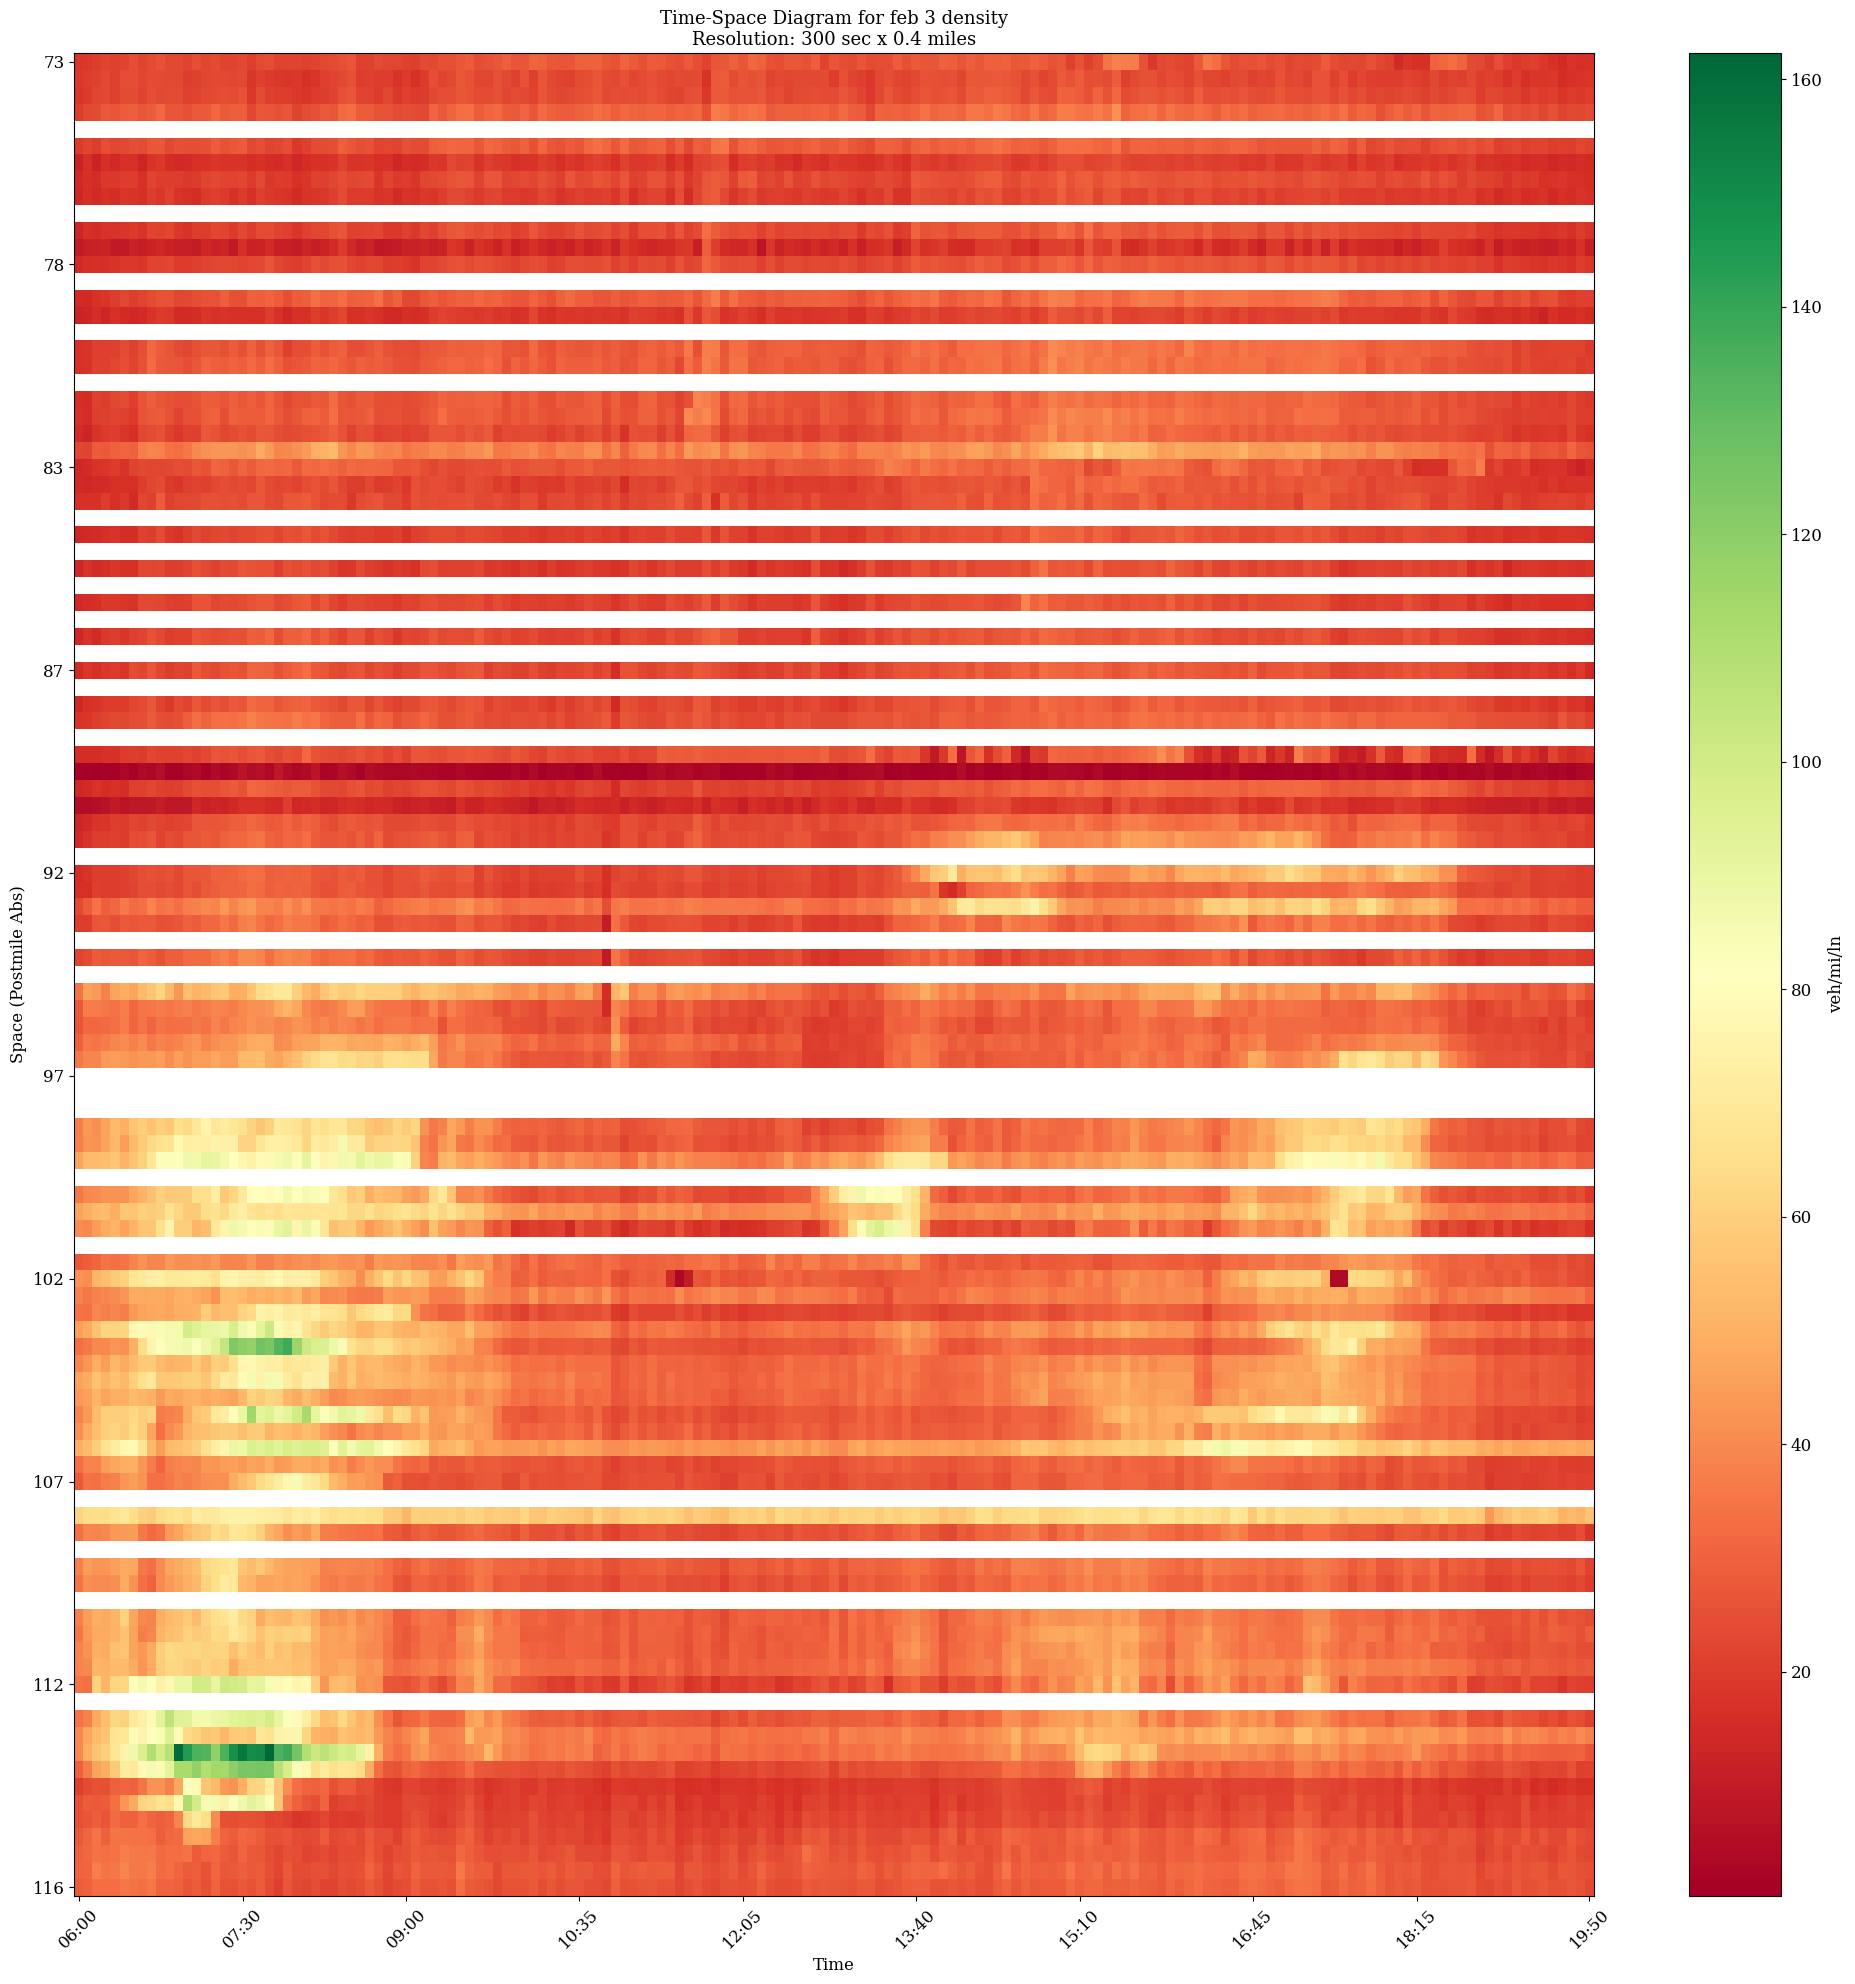

In [10]:
date_str="2026-02-05"
ref_date=pd.Timestamp(date_str)
t_min_dated = t_min + ref_date
t_max_dated = t_max + ref_date
plot_matrix(daily_density_results[date_str]["density_matrix"], 'feb 3 density', 'veh/mi/ln', t_min = t_min_dated, t_max=t_max_dated,start_pm = start_pm, end_pm = end_pm)

In [ ]:
imputed_daily_density_results = {}

for day, result in daily_density_results.items():
    m = result["density_matrix"]
    imputed_m = y_weighted_fill_or_smooth(m, mode='impute', num_neighbors=3, max_passes=5)

    imputed_daily_density_results[day] = {
        **result,
        "imputed_density_matrix": imputed_m
    }

    print(day, "before:", np.isnan(np.asarray(m, dtype=float)).sum(), "after:", np.isnan(imputed_m).sum())

2026-02-02 before: 8794 after: 5786
2026-02-03 before: 14735 after: 7085
2026-02-04 before: 13698 after: 3720
2026-02-05 before: 4008 after: 0
2026-02-06 before: 4008 after: 0
2026-02-09 before: 4342 after: 0
2026-02-10 before: 4008 after: 0
2026-02-11 before: 4008 after: 0
2026-02-12 before: 4008 after: 0
2026-02-13 before: 4008 after: 0
2026-02-17 before: 4008 after: 0
2026-02-18 before: 4009 after: 0
2026-02-19 before: 4175 after: 0
2026-02-20 before: 4010 after: 0
2026-02-23 before: 4843 after: 0
2026-02-24 before: 5678 after: 0
2026-02-25 before: 5168 after: 218
2026-02-26 before: 5345 after: 0
2026-02-27 before: 5344 after: 0


inferred time increment: 0 days 00:05:00
inferred space increment: -0.64 km
num time bins: 167
num space bins: 109
num space edges: 109


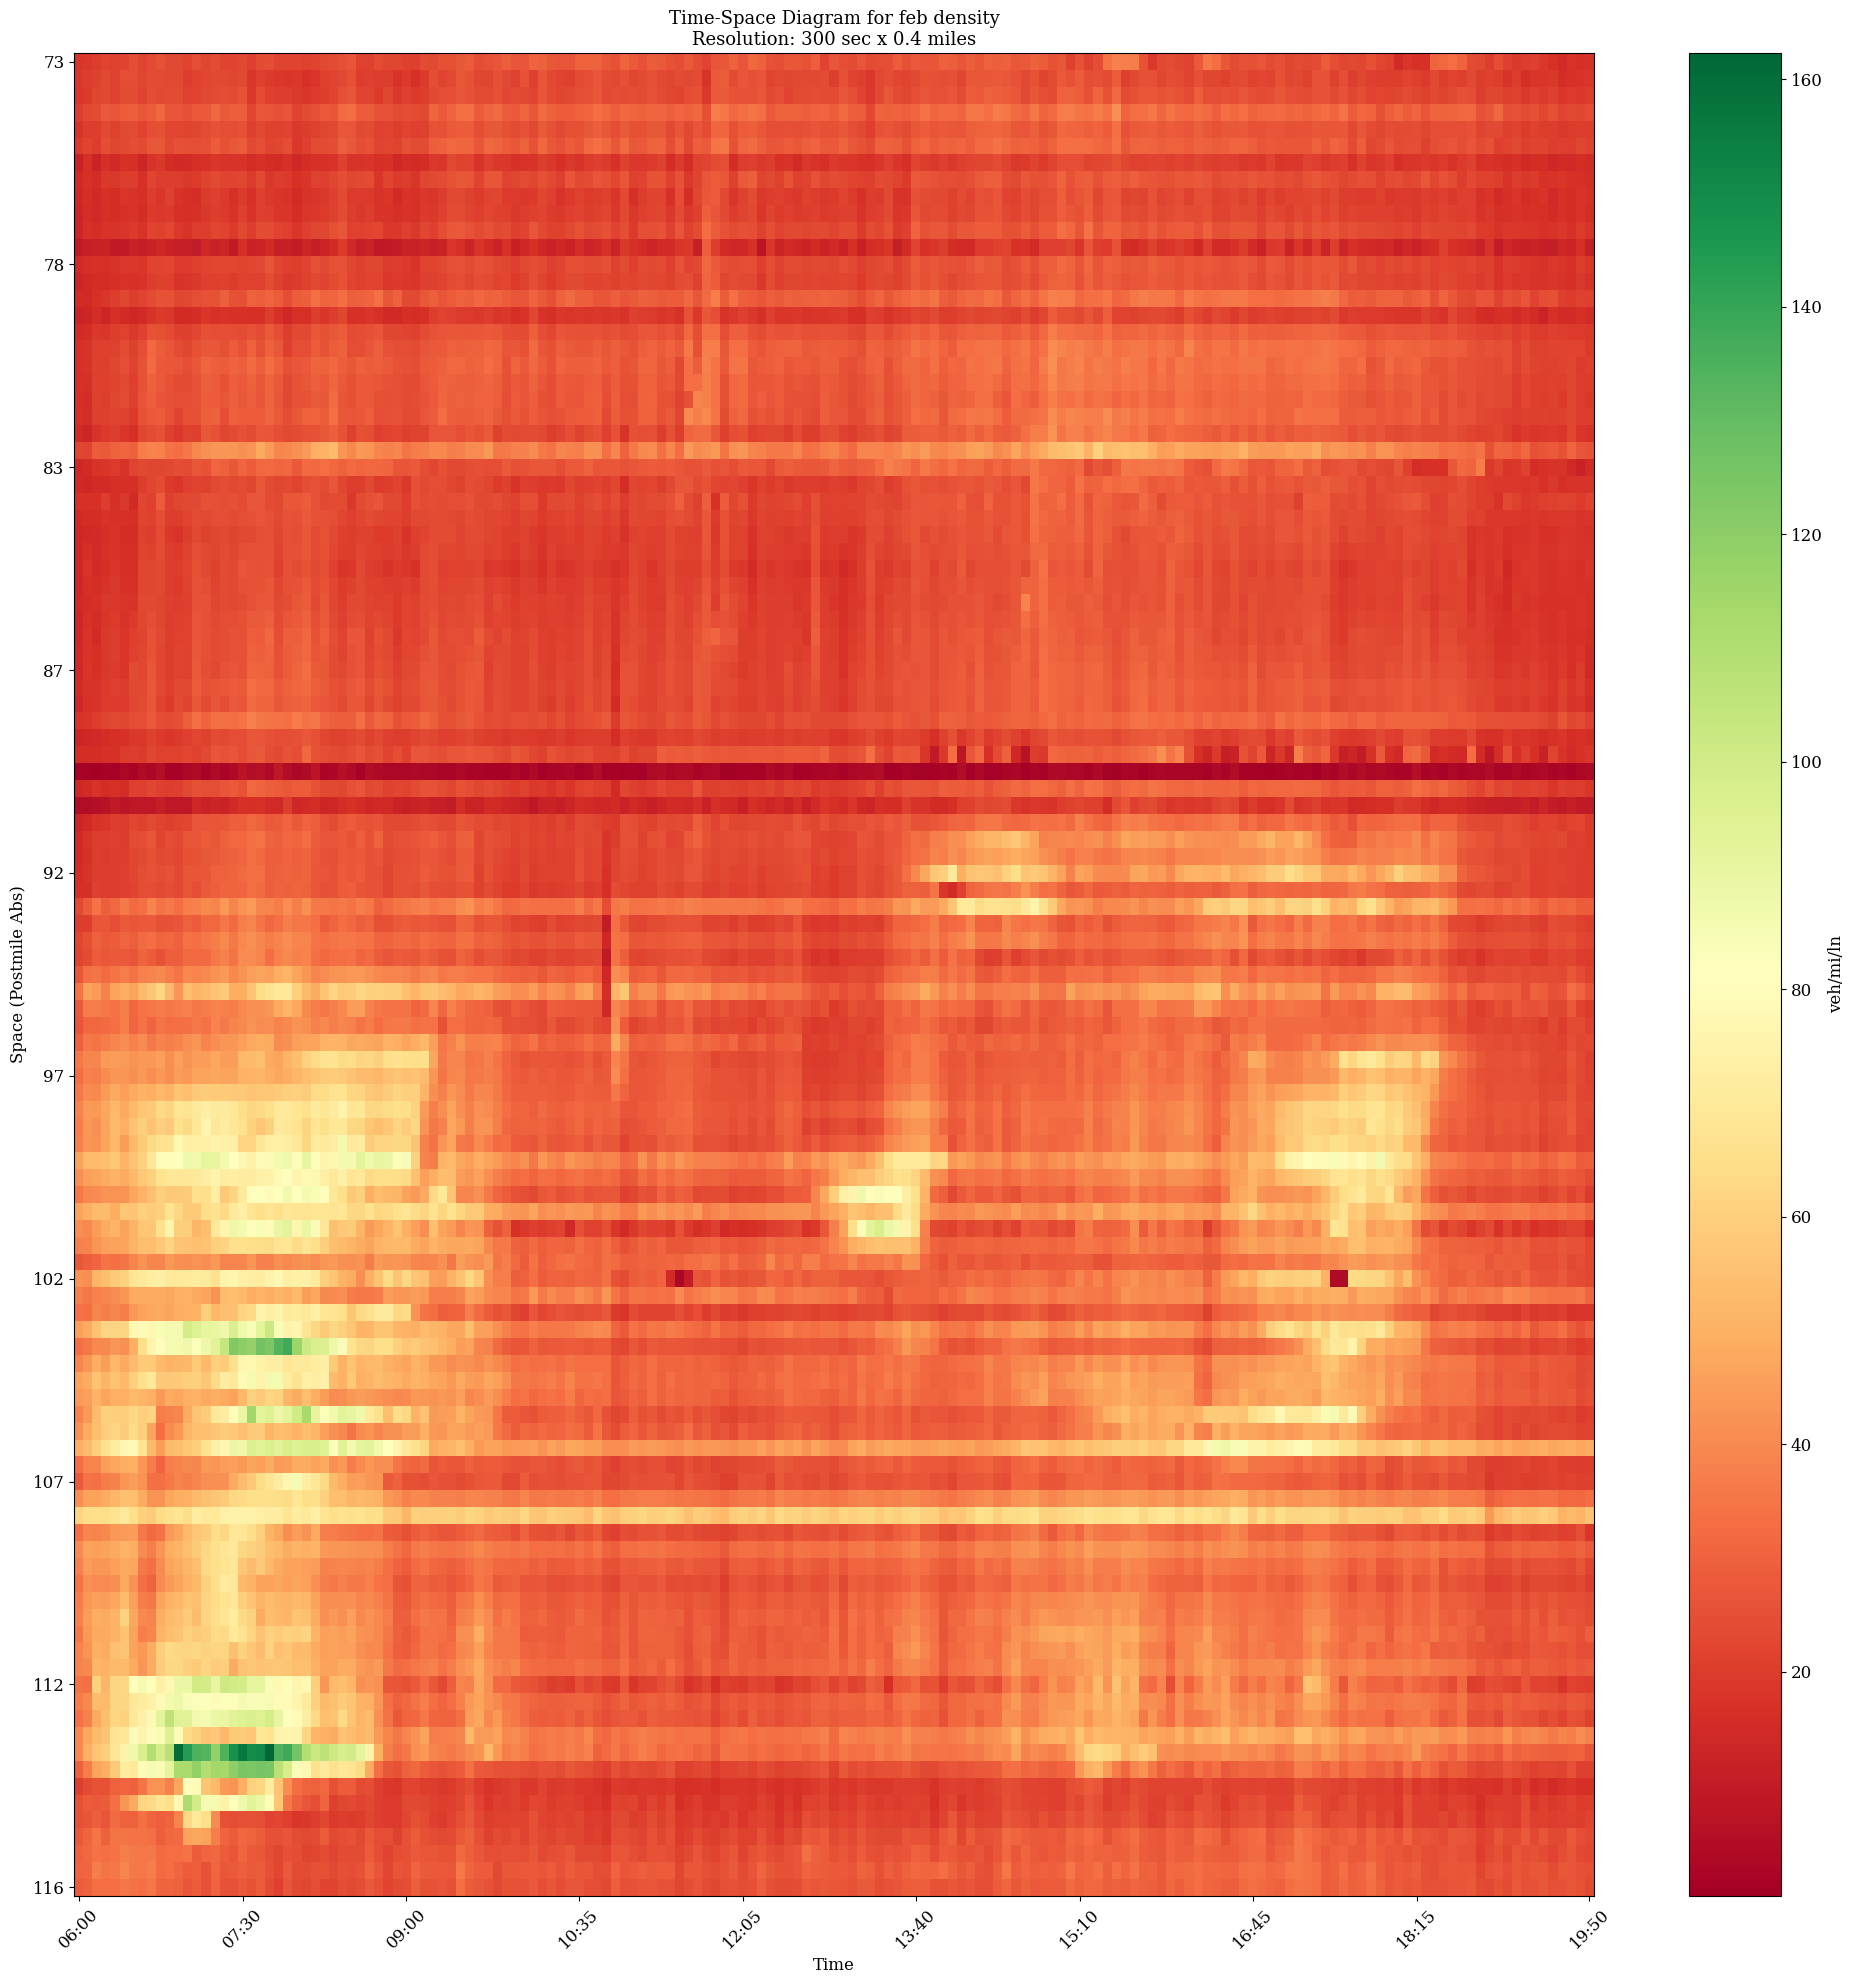

In [12]:
plot_matrix(imputed_daily_density_results[date_str]["imputed_density_matrix"], 'feb density', 'veh/mi/ln', t_min = t_min_dated, t_max=t_max_dated,start_pm = start_pm, end_pm = end_pm)

In [13]:
# Assumes:
# imputed_daily_density_results[day]["imputed_density_matrix"] exists
# and all matrices have same shape.

# Sort days for a consistent "prior" order
days = sorted(imputed_daily_density_results.keys())

rolling_density_stats = {}
prior_stack = []

# template shape from first matrix
first_mat = np.asarray(
    imputed_daily_density_results[days[0]]["imputed_density_matrix"],
    dtype=float
)
shape = first_mat.shape

for day in days:
    current = np.asarray(
        imputed_daily_density_results[day]["imputed_density_matrix"],
        dtype=float
    )

    if len(prior_stack) == 0:
        # no prior matrices yet
        prior_mean = np.full(shape, np.nan)
        prior_std = np.full(shape, np.nan)
    else:
        stack = np.stack(prior_stack, axis=0)   # (num_prior, rows, cols)
        prior_mean = np.nanmean(stack, axis=0)  # skip NaNs
        prior_std = np.nanstd(stack, axis=0)    # skip NaNs

    rolling_density_stats[day] = {
        "prior_mean_matrix": prior_mean,
        "prior_std_matrix": prior_std,
    }

    # add current matrix to priors for next iterations
    prior_stack.append(current)

/var/folders/gf/_j_dmrsx1l7dldxn8zshjgbc0000gn/T/ipykernel_21953/1978382183.py:30: RuntimeWarning: Mean of empty slice
  prior_mean = np.nanmean(stack, axis=0)  # skip NaNs
/opt/anaconda3/envs/metanet_geo/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1992: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


num time bins: 167
num space bins: 109


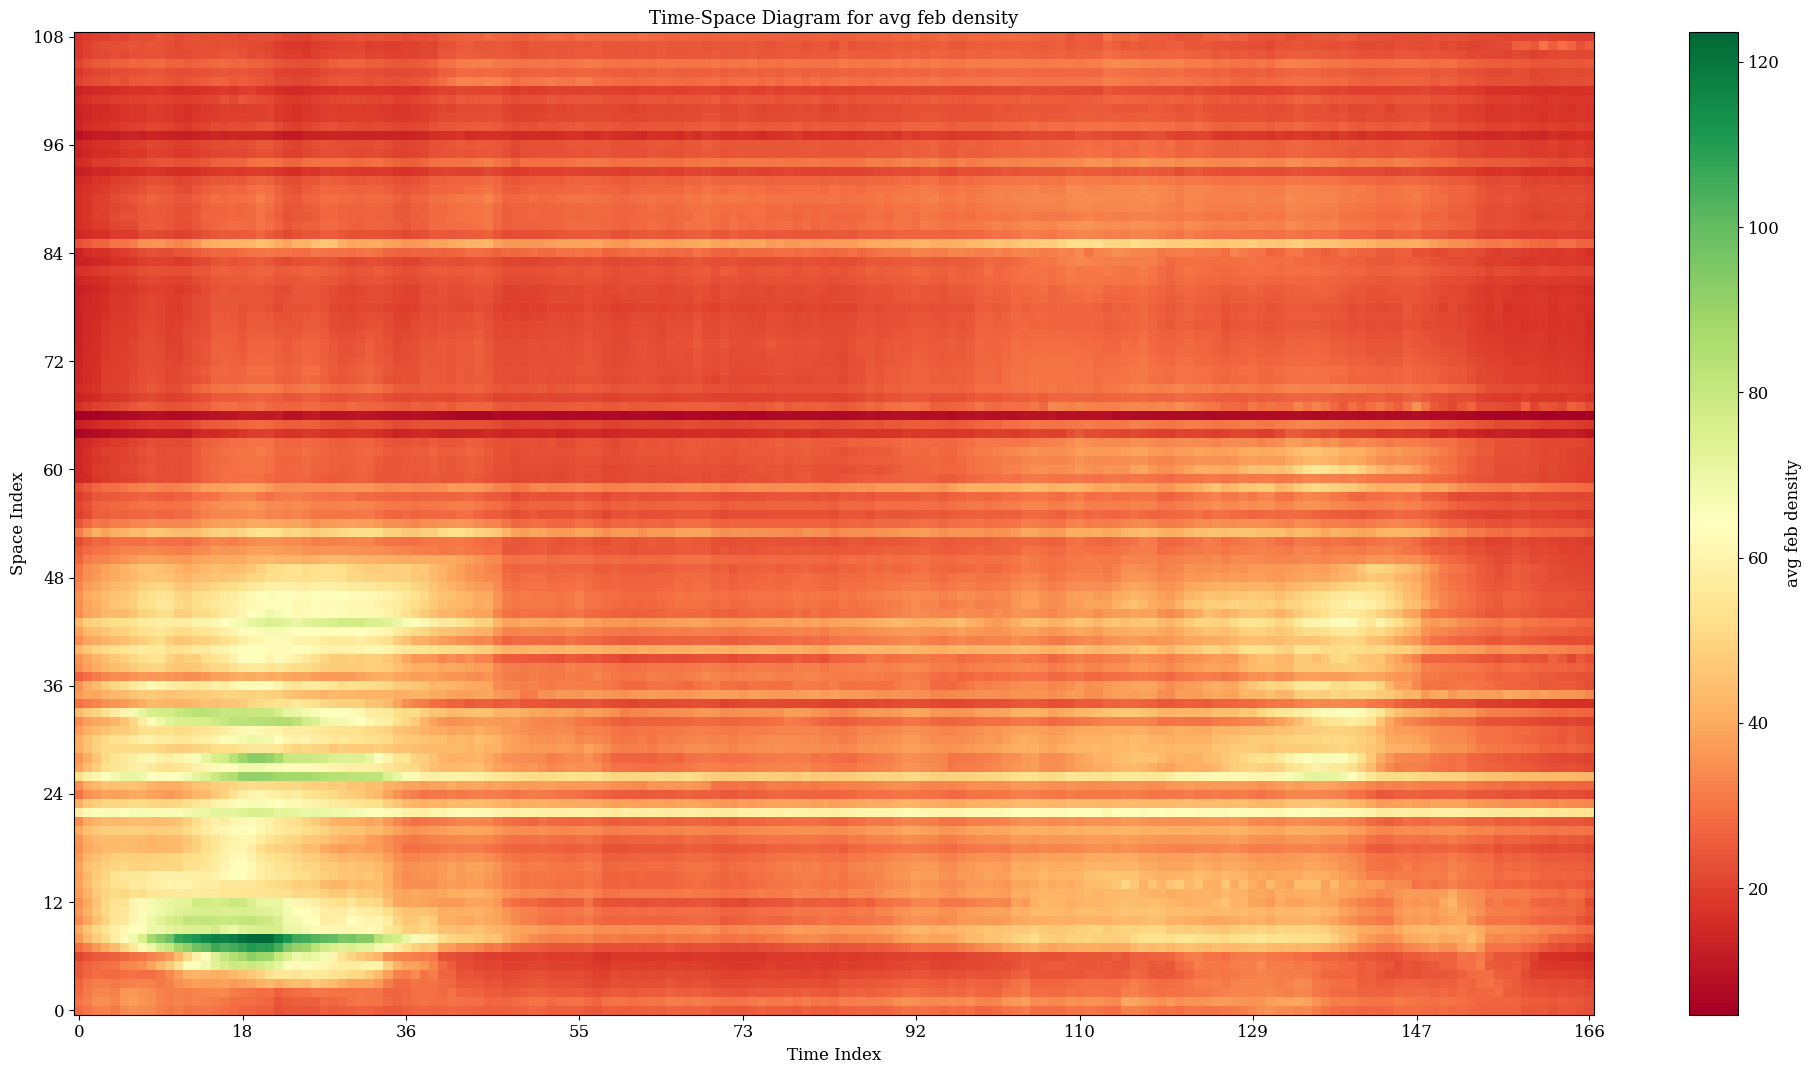

In [14]:
plot_matrix(rolling_density_stats["2026-02-27"]["prior_mean_matrix"], "avg feb density")

In [15]:
# If "final" means the last day's prior stats:
last_day = sorted(rolling_density_stats.keys())[-1]
final_mean_matrix = rolling_density_stats[last_day]["prior_mean_matrix"]
final_std_matrix = rolling_density_stats[last_day]["prior_std_matrix"]

# 1) average standard deviation across all cells (skip NaN)
avg_std_all_cells = np.nanmean(final_std_matrix)
print(f"Avg std across all cells: {avg_std_all_cells:.4f}")

# 2) percentage of cells in final mean matrix > 35 (among non-NaN cells)
valid_mask = ~np.isnan(final_mean_matrix)
pct_above_35 = (np.sum(final_mean_matrix[valid_mask] > 35) / np.sum(valid_mask)) * 100
print(f"Percent of cells in final mean matrix > 35: {pct_above_35:.2f}%")

Avg std across all cells: 5.9484
Percent of cells in final mean matrix > 35: 26.94%


num time bins: 167
num space bins: 109


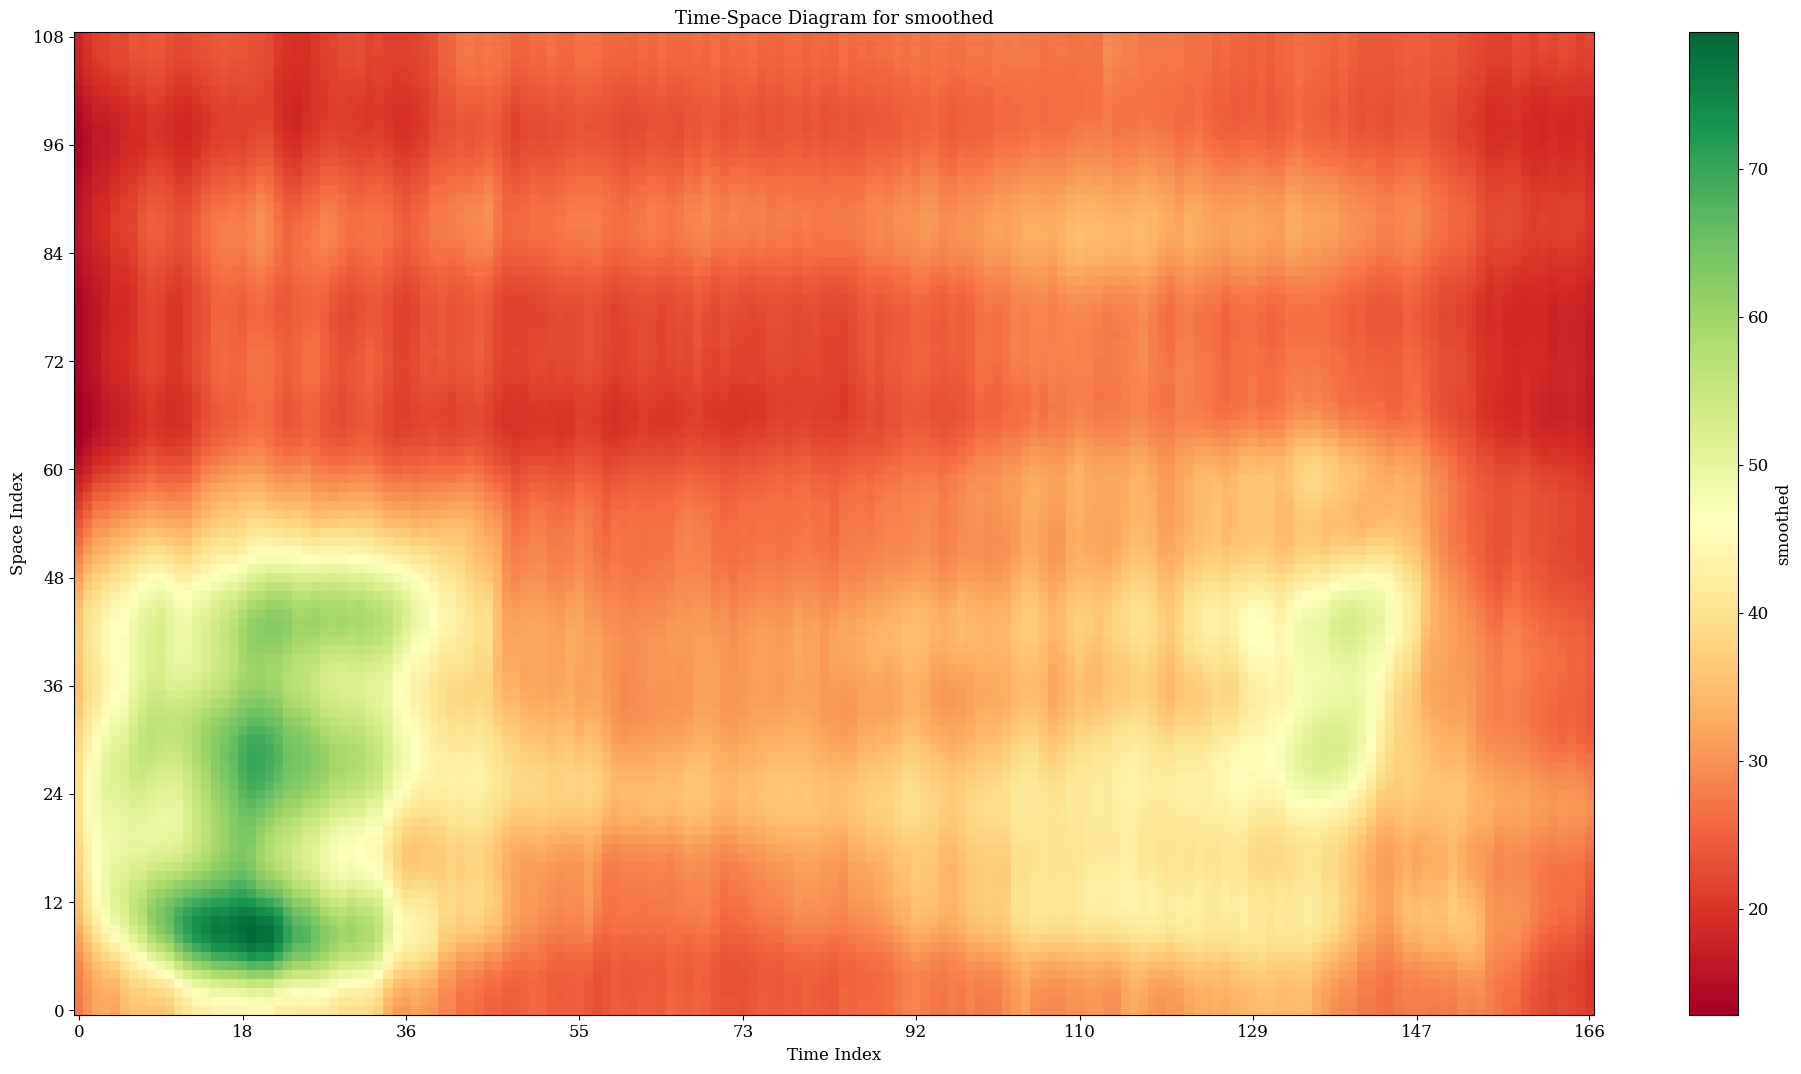

In [16]:
final_mean_matrix_smoothed = y_weighted_fill_or_smooth(final_mean_matrix, mode='smooth')
plot_matrix(final_mean_matrix_smoothed, "smoothed")

In [18]:
blocks = find_congestion_blocks_merged(final_mean_matrix_smoothed, threshold=35, connectivity=4)
print(f"Found {len(blocks)} congestion block(s)")
for i, b in enumerate(blocks, 1):
    print(
        f"Block {i}: rows {b['row_min']}-{b['row_max']}, "
        f"cols {b['col_min']}-{b['col_max']}, n_cells={b['n_cells']}"
    )

Found 4 congestion block(s)
Block 1: rows 0-57, cols 0-58, n_cells=2531
Block 2: rows 1-62, cols 84-153, n_cells=2299
Block 3: rows 21-27, cols 75-82, n_cells=41
Block 4: rows 22-27, cols 66-69, n_cells=17


In [19]:
filtered_blocks = filter_congestion_blocks(blocks, min_width_cols=6, min_height_rows=2)
for i, b in enumerate(filtered_blocks, 1):
    print(
        f"Block {i}: rows {b['row_min']}-{b['row_max']}, "
        f"cols {b['col_min']}-{b['col_max']}, n_cells={b['n_cells']}"
    )

Block 1: rows 0-57, cols 0-58, n_cells=2531
Block 2: rows 1-62, cols 84-153, n_cells=2299
Block 3: rows 21-27, cols 75-82, n_cells=41


num time bins: 167
num space bins: 109


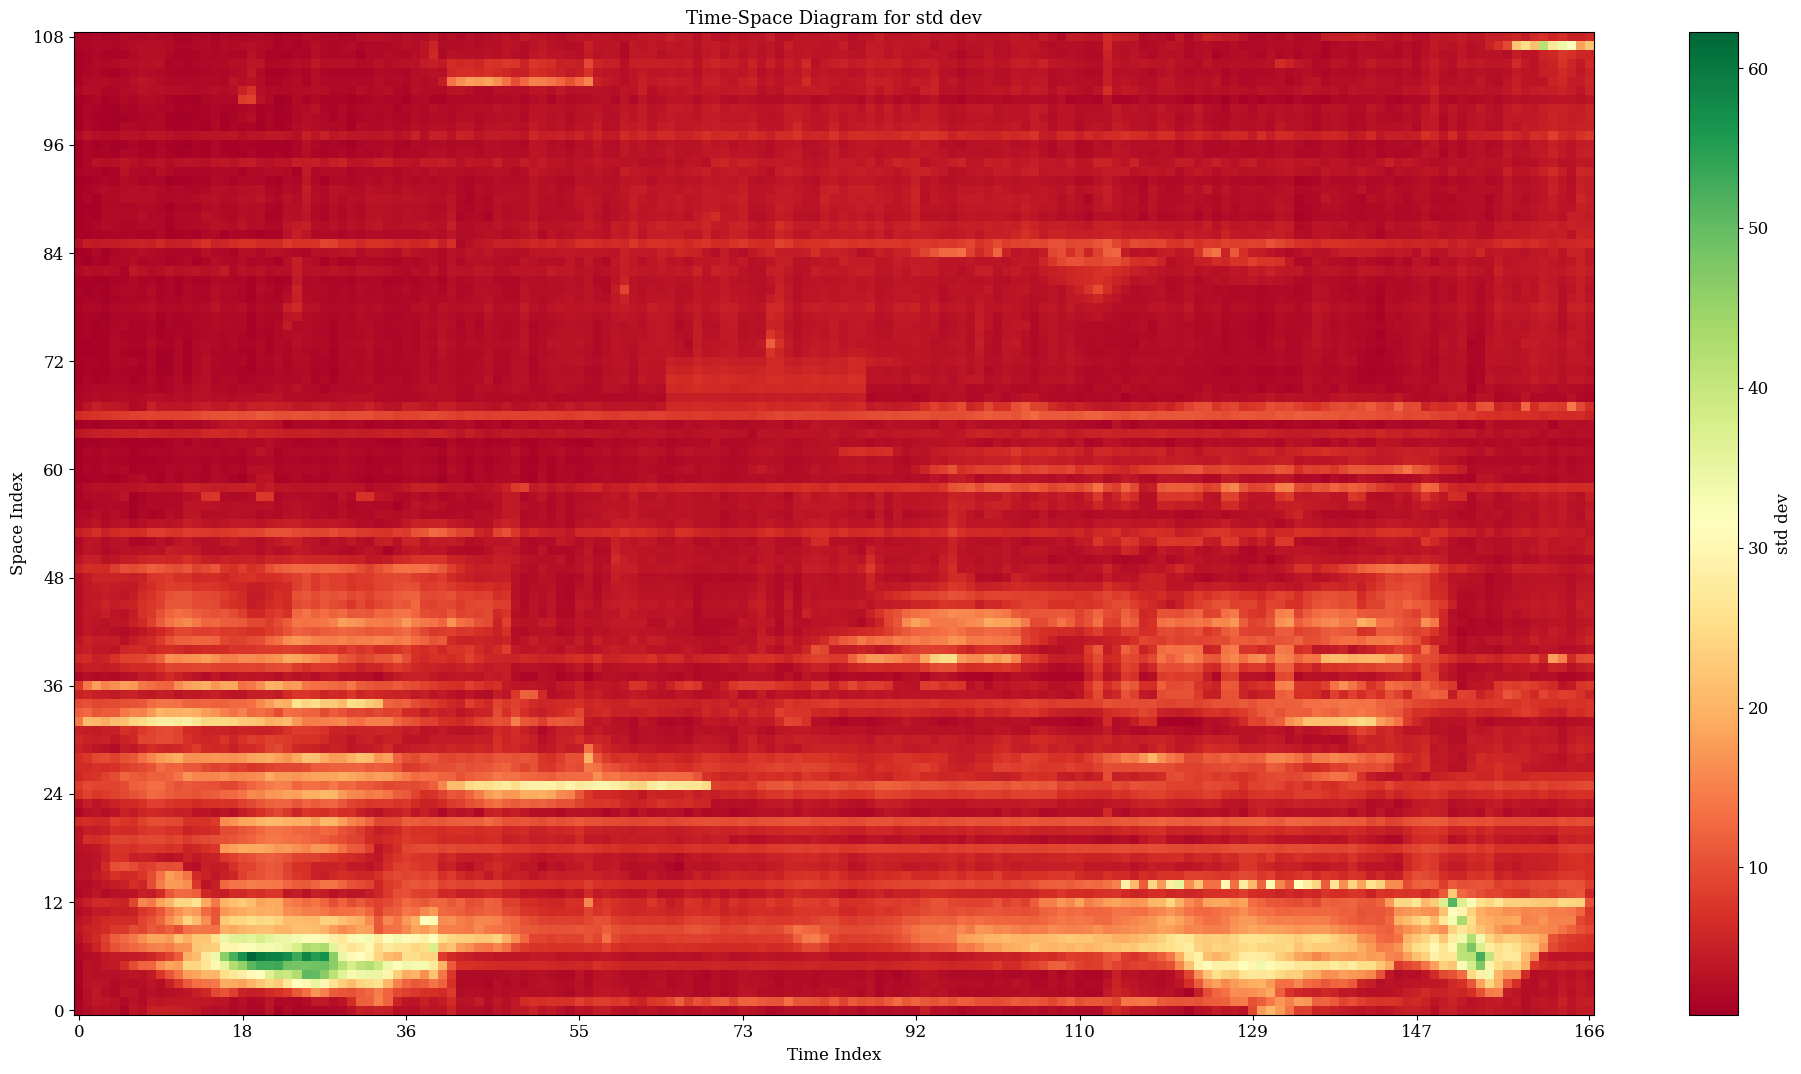

In [20]:
plot_matrix(final_std_matrix, 'std dev')